<div class="alert alert-block alert-success">

## TP — Introduction à la régression en Python avec scikit-learn

**Durée estimée : 3 heures**

---

### Objectifs pédagogiques

À la fin de ce TP, vous serez capables de :

- comprendre ce qu’est un problème de régression
- charger et explorer un dataset
- visualiser des relations entre variables
- préparer les données pour le machine learning
- entraîner plusieurs modèles de régression
- comparer leurs performances
- gérer des données plus réalistes (valeurs manquantes, variables catégorielles)

---

### Plan

PARTIE 1 — Exemple avec le dataset California Housing, et comparaison de plusieurs modèles  
PARTIE 2 — Complexification du problème avec preprocessing réaliste  
PARTIE 3 — Exercice avec un dataset médical (Diabetes)

---

### Rappel : Qu'est-ce que la régression ?

La régression consiste à prédire une **variable continue**.

Exemples en santé :
- Prédire la durée d’hospitalisation (en jours)
- Estimer un score de sévérité
- Prédire une glycémie future 
- Estimer un risque cardiovasculaire

Contrairement à la classification, la variable cible n’est pas une classe, mais un nombre continu.

---



# Guided Regression Notebook

Welcome! This notebook is a **step-by-step introduction** to **regression** in machine learning using the **California Housing dataset**.

 **Instruction**
- Short explanations in Markdown
- Code you can run directly
- Cells with **TODOs** for you to complete
- **Assertions** to check your work

> Tip: Run cells from top to bottom. If an assertion fails, read the instructions and fix your code.

# Part 1 — Guided Course with the California Housing Dataset

## 1) Pedagogical Introduction

**Regression** means predicting a **continuous numerical value**.

The California Housing dataset contains information about housing districts in California.
This dataset consists of **20,640 samples** and **9 features**:
- _MedInc_: median income in block group
- _HouseAge_: median house age in block group
- _AveRooms_: average number of rooms per household
- _AveBedrms_: average number of bedrooms per household
- _Population_: block group population
- _AveOccup_: average number of household members
- _Latitude_: block group latitude
- _Longitude_: block group longitude

The goal is to predict the **Median house value**. The target variable is expressed in hundreds of thousands of dollars ($100,000).


In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

np.random.seed(42)

## 2) Loading and Exploring the Data
We load _California Housing_ dataset from `sklearn`, then convert it to a pandas DataFrame. This makes exploration and plotting easier.

In [2]:
# Load dataset
housing = fetch_california_housing()

# Create a DataFrame with feature names
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add MedianHouseValue column wich is the target
df["MedianHouseValue"] = housing.target # Each value corresponds to the median house value in units of $100,000.

"""
BE CAREFUL:
We use a regression dataset stored in scikit-learn, but you can use any dataset you want (e.g., from a CSV file).
In that case, you will need to load the dataset using pandas (e.g., pd.read_csv) and preprocess it accordingly (e.g., handle missing values, encode categorical variables, etc.).
For simplicity, we are using the California Housing dataset, which is clean and ready for regression tasks.
"""

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())


Shape: (20640, 9)
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedianHouseValue']


The dataset contains 20,640 samples with 9 columns: 8 features (MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude) and 1 target variable (MedianHouseValue).

In [3]:
# Display the first few rows of the DataFrame 
# (by default, it shows the first 5 rows, but you can specify the number of rows to display by passing an argument to head(), e.g., df.head(10) to show the first 10 rows)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedianHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# Display information about the DataFrame, including data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MedInc            20640 non-null  float64
 1   HouseAge          20640 non-null  float64
 2   AveRooms          20640 non-null  float64
 3   AveBedrms         20640 non-null  float64
 4   Population        20640 non-null  float64
 5   AveOccup          20640 non-null  float64
 6   Latitude          20640 non-null  float64
 7   Longitude         20640 non-null  float64
 8   MedianHouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
# Display summary statistics of the DataFrame
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedianHouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 3) Visualization
We now visualize the data to understand how the Median House Value evolve depending ofeach features.

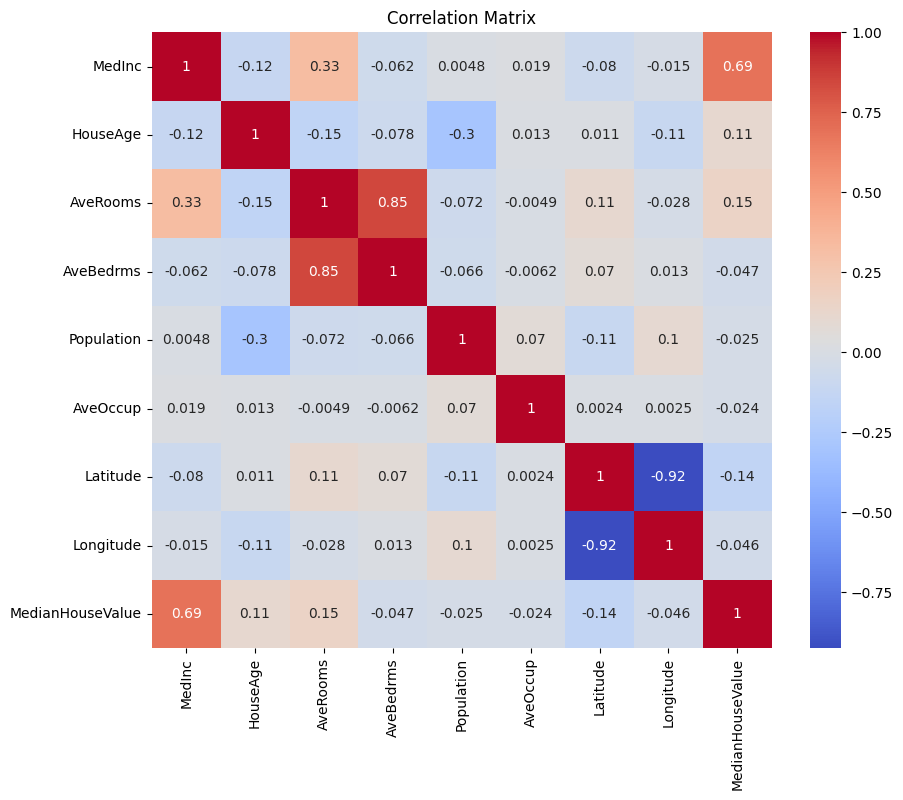

In [6]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


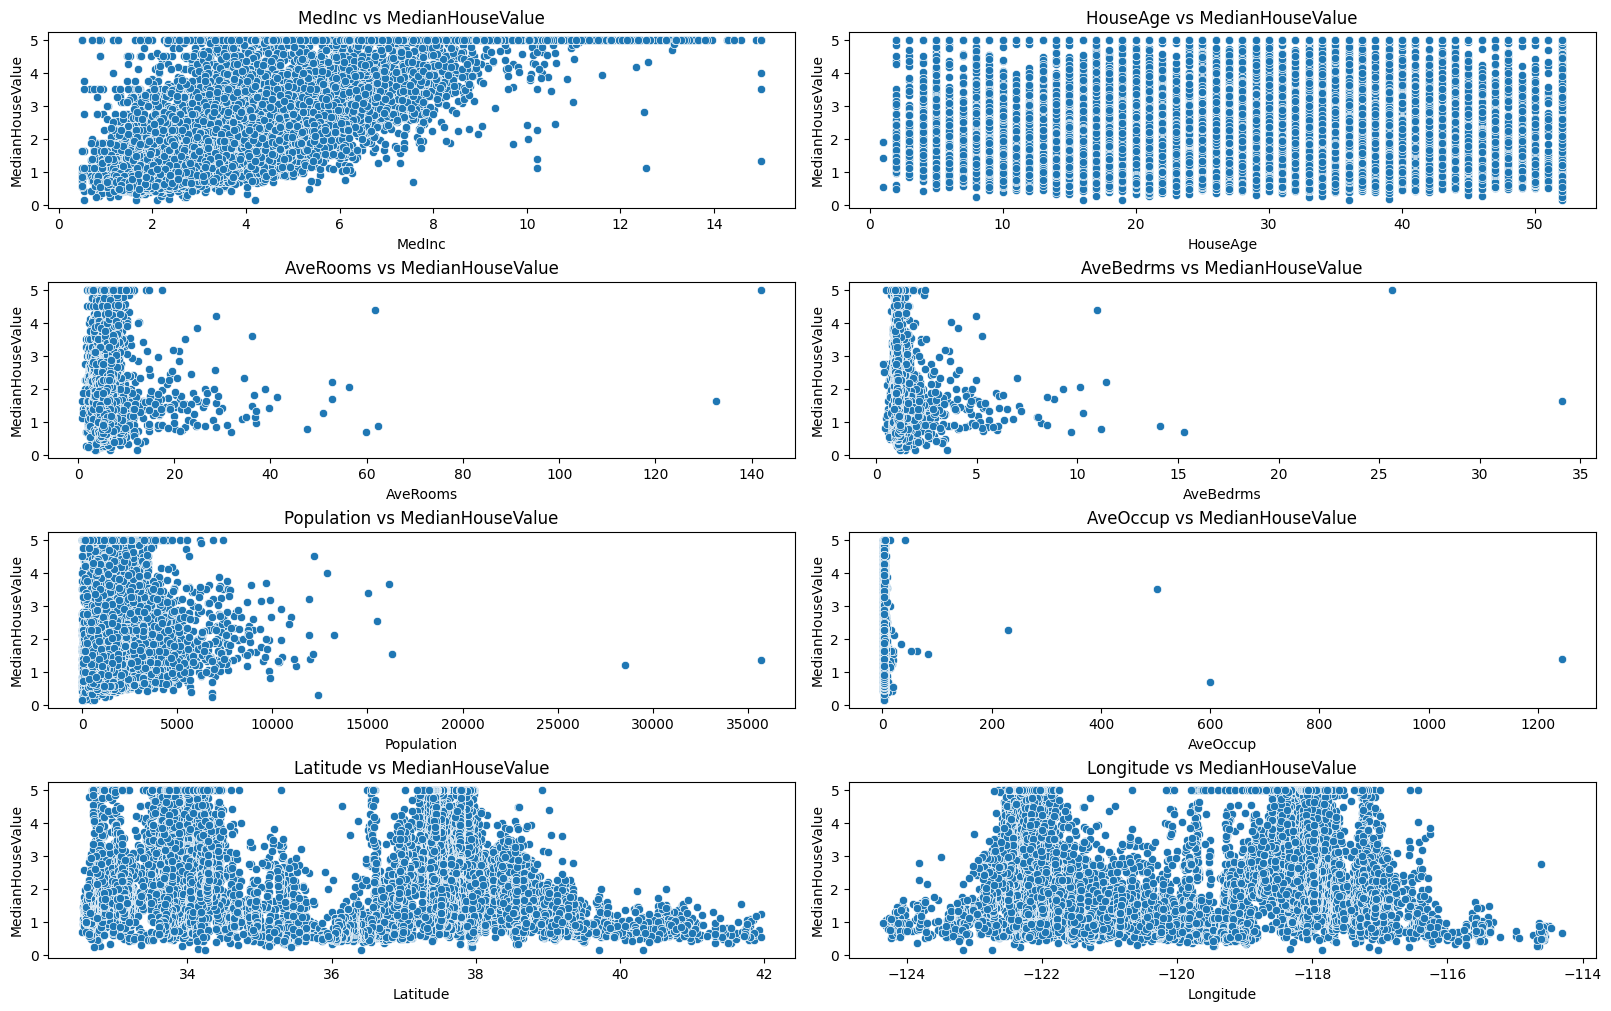

In [7]:
# Display each feature vs MedianHouseValue in a single figure
features = housing.feature_names
n_features = len(features)
n_cols = 2
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel()

for i, feature in enumerate(features):
    sns.scatterplot(x=df[feature], y=df["MedianHouseValue"], ax=axes[i])
    axes[i].set_title(f"{feature} vs MedianHouseValue")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("MedianHouseValue")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.show()

<div class="alert alert-block alert-info">
<b>Questions:</b>

- Which variable seems most correlated with the target?
- Do relationships appear linear?
</div>

MedInc shows the clearest positive relationship with MedianHouseValue (strongest signal).

## 4) Preprocessing

In [8]:
# Make a copy of the original DataFrame to modify it without affecting the original data
df_mod = df.copy()

We must separate **features** $X$ and **target** $y$, then split into **train** and **test** sets.

In [9]:
# Split the dataset into features (X) and target (y)
X = df_mod.drop("MedianHouseValue", axis=1) # We drop the target column to get only the features
y = df_mod["MedianHouseValue"] # The target variable is the "MedianHouseValue" column, which contains the Median House Value


In [10]:
# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create scaled version ONLY for models that need it
scaler = StandardScaler() # We create the scaler object.
X_train_scaled = scaler.fit_transform(X_train) # The scaler learns the mean and standard deviation from the training data (fit), then applies the scaling (transform).
X_test_scaled = scaler.transform(X_test) # We apply the same scaling parameters to the test data.

"""We only fit the scaler on the training data to avoid data leakage.  
The test set must remain unseen during training."""

# Display the shapes of the training and testing sets
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print()
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (16512, 8)
y_train shape: (16512,)

X_test shape: (4128, 8)
y_test shape: (4128,)


We use StandardScaler to standardize the features so that they all have:

- Mean = 0  
- Standard deviation = 1  

This prevents features with large values (for example Population) from dominating features with smaller values (for example Median Income).

## 5) Train Baseline Classifiers
We will train several common models and compare their metrics.

We store them in a dictionary and loop through them.

In [11]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=20, random_state=42),
    "KNN (no scaling)": KNeighborsRegressor(n_neighbors=5),
    "KNN (with scaling)": KNeighborsRegressor(n_neighbors=5)
}

results = {}

for name, model in models.items():
    if name == "Linear Regression" or name == "KNN (with scaling)":
        model.fit(X_train_scaled, y_train) # Train the model on the scaled training data
        preds = model.predict(X_test_scaled) # Make predictions on the scaled test set
    else:
        model.fit(X_train, y_train) # Train the model on the training data
        preds = model.predict(X_test) # Make predictions on the test set

    # Calculate evaluation metrics for the model
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results[name] = {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

# Create a DataFrame from the results dictionary for better visualization
results_df = pd.DataFrame(results).T # Transpose the DataFrame to have models as rows and metrics as columns
results_df.head()

,MSE,RMSE,MAE,R2
Linear Regression,0.555892,0.745581,0.533200,0.575788
Decision Tree,0.499707,0.706900,0.455762,0.618663
Random Forest,0.262803,0.512644,0.335321,0.799449
KNN (no scaling),1.118682,1.057678,0.812798,0.146310
KNN (with scaling),0.432422,0.657588,0.446154,0.670010


In classification, we predict **categories** (for example: sick / healthy, or iris species).  
This allows us to count correct and incorrect predictions, and use metrics such as:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

In regression, the goal is different. We predict a **continuous numerical value**, such as:

- house price
- temperature
- disease progression score

Since predictions are numerical, they are almost never exactly correct. Instead, we measure **how far the prediction is from the true value**.

We define the prediction error as:

\[
error = y_{true} - y_{predicted}
\]

Regression metrics measure the size of this error.

---

### 1. Mean Squared Error (MSE)

Definition:

\[
MSE = \frac{1}{n} \sum (y_{true} - y_{predicted})^2
\]

It is the average of the squared errors.

Properties:

- Range: **0 to +∞**
- Best value: **0**
- Lower is better
- Penalizes large errors more strongly (because of the square)

Example interpretation:

- MSE close to 0 → very good model
- Large MSE → poor model

---

### 2. Root Mean Squared Error (RMSE)

Definition:

\[
RMSE = \sqrt{MSE}
\]

Properties:

- Range: **0 to +∞**
- Best value: **0**
- Lower is better
- Same unit as the target variable

This makes RMSE easier to interpret.

Example:

If predicting house prices and RMSE = 10,000, the model makes an average error of about $10,000.

---

### 3. Mean Absolute Error (MAE)

Definition:

\[
MAE = \frac{1}{n} \sum |y_{true} - y_{predicted}|
\]

Properties:

- Range: **0 to +∞**
- Best value: **0**
- Lower is better
- Represents the average absolute error

Example:

MAE = 8 means the prediction is off by 8 units on average.

Difference with RMSE:

- MAE treats all errors equally
- RMSE penalizes large errors more strongly

---

### 4. R² Score (Coefficient of Determination)

Definition:

Measures how well the model explains the variability of the data.

Properties:

- Range: **−∞ to 1**
- Best value: **1**
- Higher is better

Interpretation:

- R² = 1 → perfect predictions
- R² = 0 → model is no better than predicting the average
- R² < 0 → model is worse than predicting the average

Example interpretation:

- R² = 0.90 → excellent model
- R² = 0.70 → good model
- R² = 0.40 → moderate model
- R² ≤ 0 → poor model

---

### Summary Table

| Metric | Meaning | Range | Best value |
|------|---------|--------|------------|
| MSE | Average squared error | 0 to +∞ | 0 |
| RMSE | Average error (interpretable unit) | 0 to +∞ | 0 |
| MAE | Average absolute error | 0 to +∞ | 0 |
| R² | Overall model quality | −∞ to 1 | 1 |

---

### Intuitive Interpretation

- MAE / RMSE → how much the model is wrong on average
- R² → how good the model is overall

Good regression model:

- Low MAE
- Low RMSE
- Low MSE
- High R² (close to 1)


## 6) Compare Models
We create a bar chart of accuracies and identify the best model.

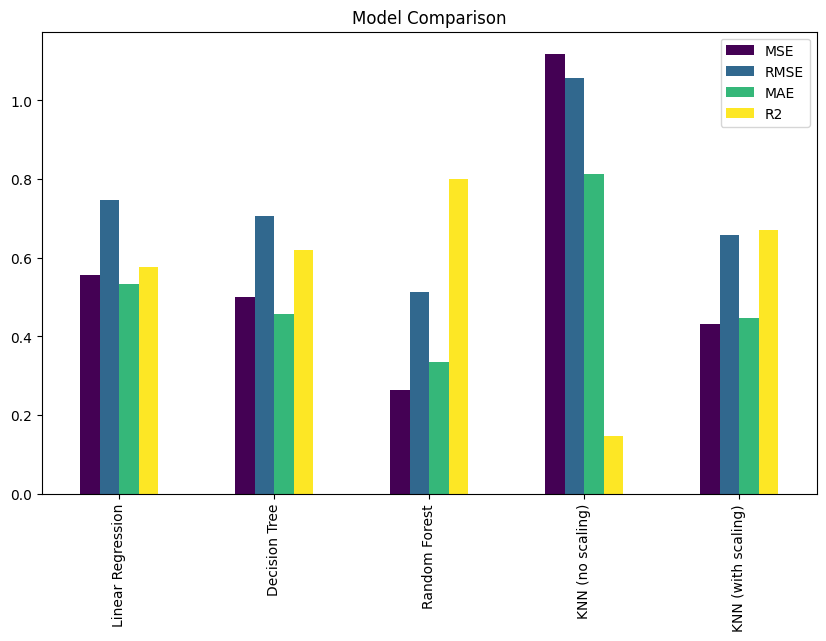

In [12]:
results_df.plot(kind="bar", figsize=(10,6), colormap="viridis")
plt.title("Model Comparison")
plt.show()

### Why Were Results Much Better with Iris?

In the previous classification TP, we used the **Iris dataset**.  
Many students obtained very high scores (often above 90% accuracy).  
With the California Housing dataset, results may seem much worse.

This is completely normal.

---

#### 1. Iris is a Simple and Clean Dataset

The Iris dataset is:

- Small (150 samples)
- Well structured
- Nearly linearly separable
- Designed for pedagogy

The three classes (species) are relatively easy to distinguish using only a few features.  
Even simple models such as Logistic Regression or KNN perform extremely well.

In other words:

- The signal is strong  
- The noise is low  
- The separation between classes is clear  

This naturally leads to high performance.

---

#### 2. California Housing is a Real-World Dataset

The California Housing dataset is very different:

- Large dataset (20,000+ samples)
- Real socio-economic data
- Noisy and heterogeneous
- Relationships are not purely linear

House prices depend on many complex and interacting factors:

- Income
- Location
- Population density
- Housing age
- And many unobserved variables

There is no simple clean separation or perfect pattern.

---

#### 3. Regression is Harder Than Classification

In classification (Iris):

The prediction is either correct or incorrect.

In regression (Housing):

The prediction must match a precise numerical value.

Example:

True value = 2.5  
Prediction = 2.4 → small error  
Prediction = 1.7 → larger error  

Even a good model will almost never predict the exact value.

This makes regression naturally more difficult.

---

#### 4. Realistic Expectations

For California Housing:

- Linear Regression: R² around 0.55–0.65 → normal
- Random Forest: R² around 0.75–0.85 → very good

A model with R² = 0.60 is not bad.  
It means the model explains 60% of the variability in house prices.

In real-world problems, this is already a solid result.

---

#### 5. Key Takeaway

Iris was designed to be easy and educational.

California Housing is closer to real life.

Lower scores do not mean your model is wrong, 
they reflect the complexity and noise of real-world data.

This is an important lesson in machine learning:

Perfect accuracy is rare outside toy datasets.

# Part 2 — Further Exploration and Challenges
We now make the dataset more realistic by adding **categorical features**, **missing values**, and **class imbalance**.

This requires additional preprocessing steps before training models.

We will:
1. Add one categorical column: `Zone`
2. Inject missing values randomly
3. Create class imbalance by downsampling one class

In [13]:
df_hard = df.copy()

# Add categorical feature
zones = ["Urban", "Suburban", "Rural"]
df_hard["Zone"] = np.random.choice(zones, size=len(df_hard))

# Add unnecessary ID column
df_hard["RecordID"] = np.arange(len(df_hard))

# Inject missing values
for col in df_hard.columns:
    mask = np.random.rand(len(df_hard)) < 0.15
    df_hard.loc[mask, col] = np.nan

# Display the first few rows of the modified DataFrame to verify the changes
df_hard.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedianHouseValue,Zone,RecordID
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,Rural,0.0
1,8.3014,NaN,6.238137,0.971880,2401.0,NaN,37.86,NaN,3.585,Urban,1.0
2,7.2574,52.0,8.288136,1.073446,NaN,NaN,37.85,-122.24,3.521,NaN,2.0
3,5.6431,52.0,5.817352,1.073059,558.0,NaN,37.85,-122.25,3.413,Rural,3.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,NaN,-122.25,3.422,Urban,NaN


In [14]:
# Print the number of missing values in each column to verify that missing values were injected
print("Missing values in each column:")
print(df_hard.isnull().sum())

Missing values in each column:
MedInc              3067
HouseAge            3110
AveRooms            3052
AveBedrms           3158
Population          3094
AveOccup            3128
Latitude            3045
Longitude           3068
MedianHouseValue    3004
Zone                3154
RecordID            3084
dtype: int64


In [15]:
# Display information about the modified DataFrame to verify the changes
df_hard.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MedInc            17573 non-null  float64
 1   HouseAge          17530 non-null  float64
 2   AveRooms          17588 non-null  float64
 3   AveBedrms         17482 non-null  float64
 4   Population        17546 non-null  float64
 5   AveOccup          17512 non-null  float64
 6   Latitude          17595 non-null  float64
 7   Longitude         17572 non-null  float64
 8   MedianHouseValue  17636 non-null  float64
 9   Zone              17486 non-null  str    
 10  RecordID          17556 non-null  float64
dtypes: float64(10), str(1)
memory usage: 1.7 MB


In [16]:
# Display the description of the modified DataFrame to verify the changes
df_hard.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedianHouseValue,RecordID
count,17573.000000,17530.000000,17588.000000,17482.000000,17546.000000,17512.000000,17595.000000,17572.000000,17636.000000,17556.000000
mean,3.873806,28.659384,5.405052,1.095019,1419.363388,3.092040,35.632955,-119.570401,2.068402,10308.192071
std,1.890075,12.609421,1.997734,0.468127,1134.829301,11.261402,2.135830,2.001701,1.151649,5951.262691
min,0.499900,1.000000,0.846154,0.333333,5.000000,0.692308,32.550000,-124.350000,0.149990,0.000000
25%,2.564300,18.000000,4.438356,1.006037,785.000000,2.428138,33.930000,-121.790000,1.201750,5155.750000
50%,3.541700,29.000000,5.229190,1.048576,1162.000000,2.819632,34.250000,-118.500000,1.798000,10298.500000
75%,4.763000,37.000000,6.047464,1.099379,1719.750000,3.282862,37.720000,-118.010000,2.646250,15468.250000
max,15.000100,52.000000,59.875000,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010,20639.000000


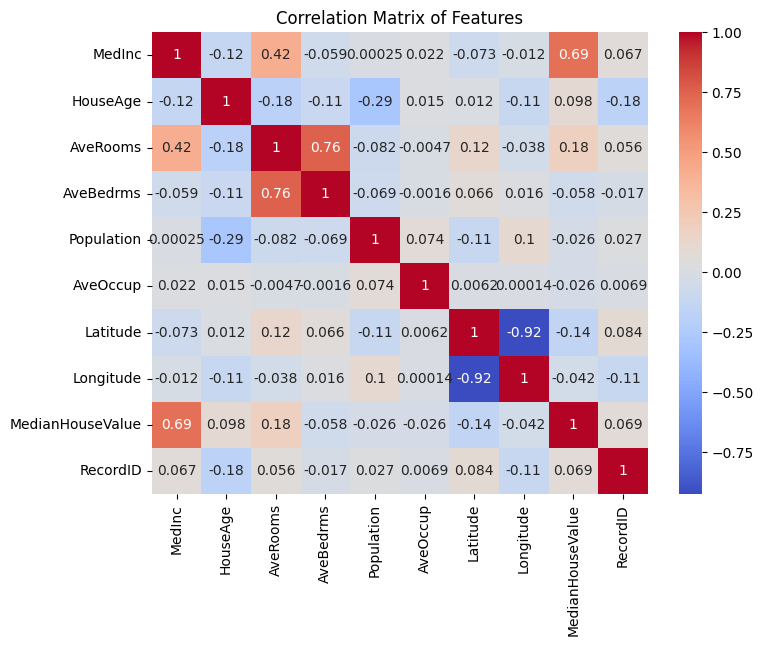

In [17]:
# Display correlation matrix of the features
plt.figure(figsize=(8, 6))
sns.heatmap(df_hard.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Features')
plt.show()

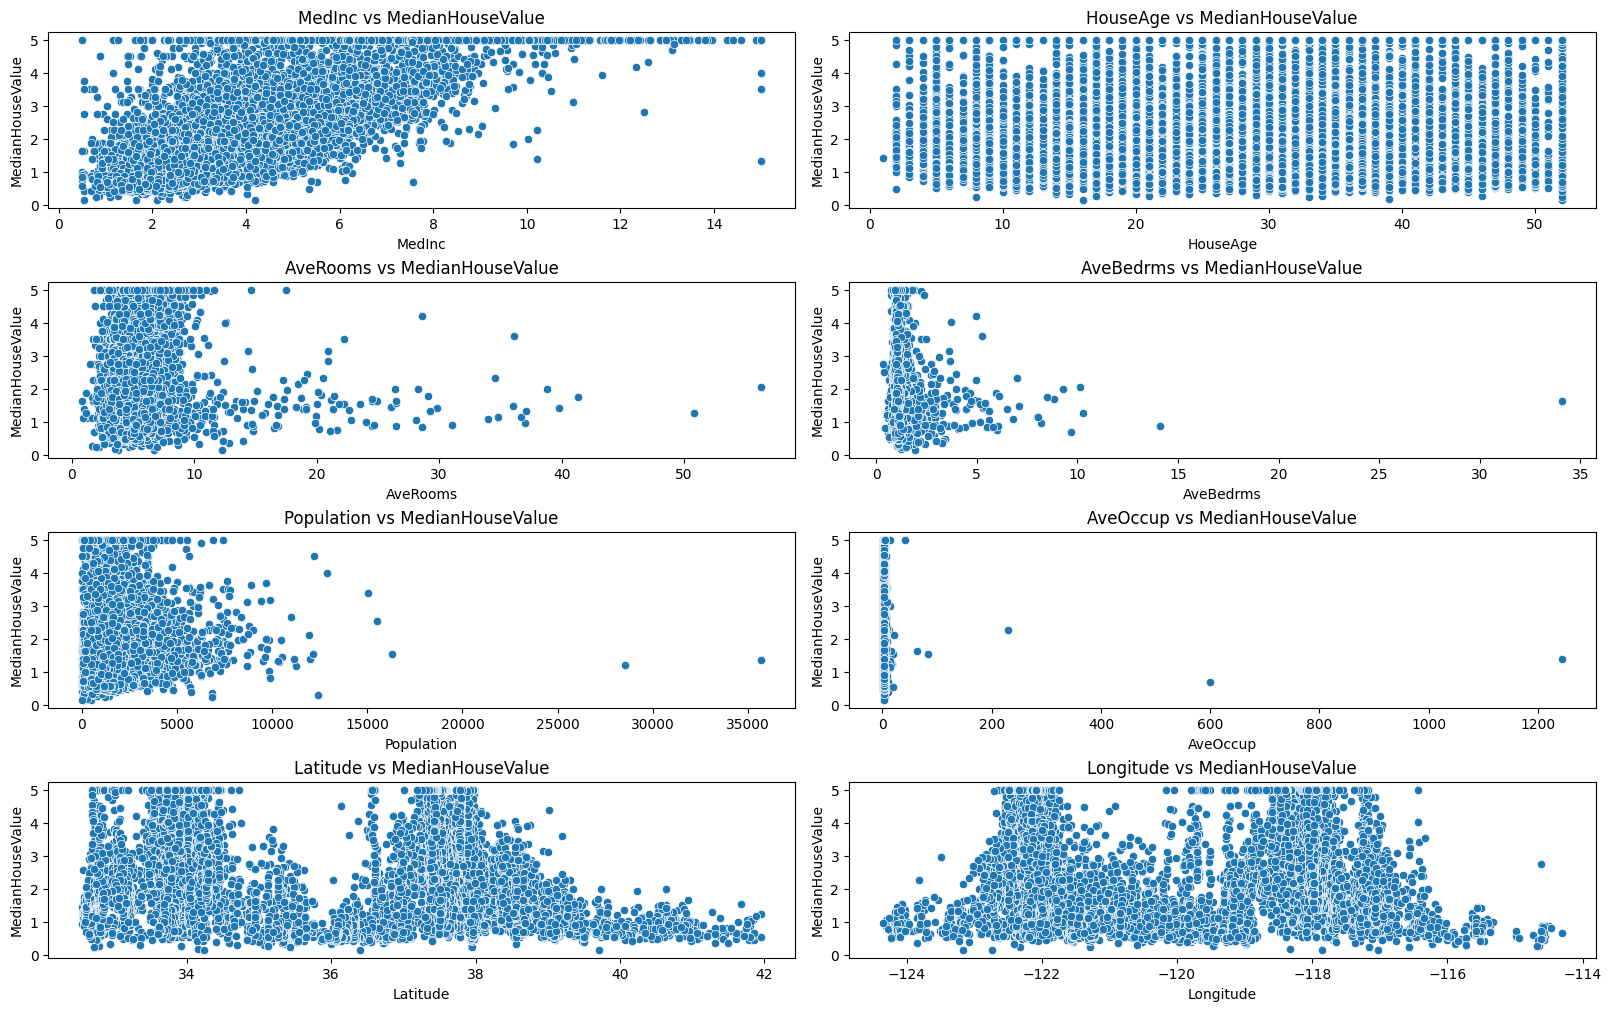

In [18]:
# Display each feature vs MedianHouseValue in a single figure
features = df_hard.columns.drop(["MedianHouseValue", "Zone", "RecordID"]).tolist()
n_features = len(features)
n_cols = 2
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel()

for i, feature in enumerate(features):
    sns.scatterplot(x=df_hard[feature], y=df_hard["MedianHouseValue"], ax=axes[i])
    axes[i].set_title(f"{feature} vs MedianHouseValue")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("MedianHouseValue")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.show()

Now we clean the dataset and prepare preprocessing tools:
- Drop unnecessary columns
- Handle missing values
- Encode categorical variables


In [19]:
# Make a copy of the hard DataFrame to clean it without affecting the hard DataFrame
df_clean = df_hard.copy()

# Drop unnecessary columns (e.g., "RecordID")
df_clean = df_clean.drop("RecordID", axis=1) # Drop the unnecessary "RecordID" column

# Drop missing values (e.g., by dropping rows with missing values)
df_clean = df_clean.dropna() # Drop rows with any missing values

# Encode categorical variable
df_clean = pd.get_dummies(df_clean, columns=["Zone"], drop_first=True, dtype=int) # This will create new binary columns for each category in "Zone", and drop the first category to avoid multicollinearity

# Print information about the cleaned DataFrame to verify the changes
df_clean.info()

# Display the first few rows of the cleaned DataFrame to verify the changes
df_clean.head()


<class 'pandas.DataFrame'>
Index: 4100 entries, 0 to 20639
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MedInc            4100 non-null   float64
 1   HouseAge          4100 non-null   float64
 2   AveRooms          4100 non-null   float64
 3   AveBedrms         4100 non-null   float64
 4   Population        4100 non-null   float64
 5   AveOccup          4100 non-null   float64
 6   Latitude          4100 non-null   float64
 7   Longitude         4100 non-null   float64
 8   MedianHouseValue  4100 non-null   float64
 9   Zone_Suburban     4100 non-null   int64  
 10  Zone_Urban        4100 non-null   int64  
dtypes: float64(9), int64(2)
memory usage: 384.4 KB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedianHouseValue,Zone_Suburban,Zone_Urban
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,0,0
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697,0,1
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267,0,0
14,1.9167,52.0,4.262903,1.009677,1212.0,1.954839,37.85,-122.26,1.592,1,0
19,2.6033,52.0,5.465455,1.083636,690.0,2.509091,37.84,-122.27,1.629,1,0


Lets split into features and target, then training and testing sets.

In [20]:
# Split the cleaned dataset into features (X) and target (y)
X_hard = df_clean.drop("MedianHouseValue", axis=1) # We drop the target column to get only the features
y_hard = df_clean["MedianHouseValue"] # The target variable is the "MedianHouseValue" column

# Split into training and testing sets (80% train, 20% test)
X_train_hard, X_test_hard, y_train_hard, y_test_hard = train_test_split(X_hard, y_hard, test_size=0.2, random_state=42)

# Create scaled version ONLY for models that need it
scaler_hard = StandardScaler()
X_train_hard_scaled = scaler_hard.fit_transform(X_train_hard) # Fit the scaler on the training data and transform it
X_test_hard_scaled = scaler_hard.transform(X_test_hard) # Transform the test set using the same scaler

# Display the shapes of the training and testing sets
print("X_train_hard shape:", X_train_hard.shape)
print("y_train_hard shape:", y_train_hard.shape)
print()
print("X_test_hard shape:", X_test_hard.shape)
print("y_test_hard shape:", y_test_hard.shape)

X_train_hard shape: (3280, 10)
y_train_hard shape: (3280,)

X_test_hard shape: (820, 10)
y_test_hard shape: (820,)


Lets train and evaluate the differents models.

In [21]:
results_hard = {}

for name, model in models.items():
    if name == "KNN (with scaling)":
        model.fit(X_train_hard_scaled, y_train_hard) # Train the model on the scaled training data
        preds_hard = model.predict(X_test_hard_scaled) # Make predictions on the scaled test set
    else:
        model.fit(X_train_hard, y_train_hard) # Train the model on the training data
        preds_hard = model.predict(X_test_hard) # Make predictions on the test set

    # Calculate evaluation metrics for the model
    mse_hard = mean_squared_error(y_test_hard, preds_hard)
    rmse_hard = np.sqrt(mse_hard)
    mae_hard = mean_absolute_error(y_test_hard, preds_hard)
    r2_hard = r2_score(y_test_hard, preds_hard)

    results_hard[name] = {
        "MSE": mse_hard,
        "RMSE": rmse_hard,
        "MAE": mae_hard,
        "R2": r2_hard
    }

# Create a DataFrame from the results dictionary for better visualization
results_hard_df = pd.DataFrame(results_hard).T # Transpose the DataFrame
results_hard_df.head()

,MSE,RMSE,MAE,R2
Linear Regression,0.518207,0.719866,0.532608,0.638538
Decision Tree,0.697952,0.835435,0.557514,0.513162
Random Forest,0.334543,0.578397,0.398329,0.766648
KNN (no scaling),1.423977,1.193305,0.932072,0.006742
KNN (with scaling),0.583497,0.763870,0.554581,0.592997


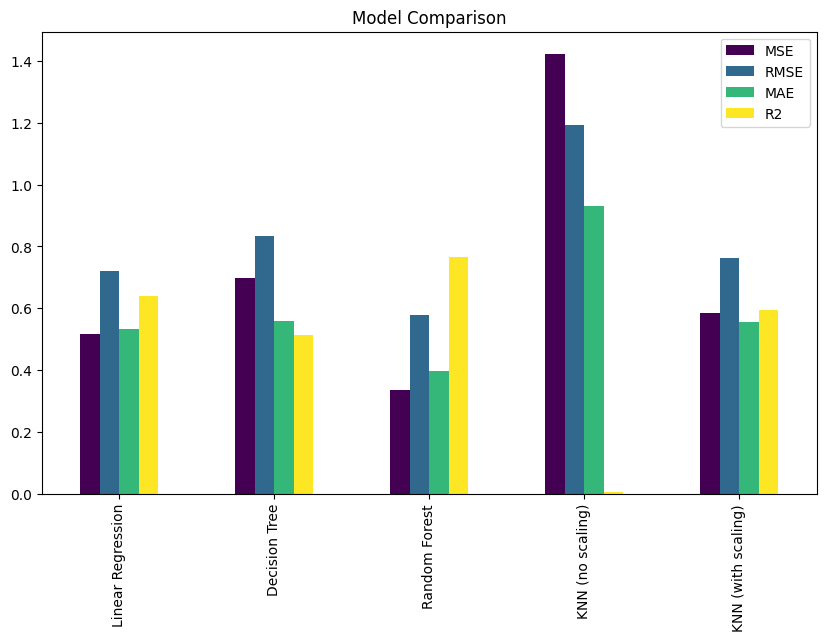

In [22]:
results_hard_df.plot(kind="bar", figsize=(10,6), colormap="viridis")
plt.title("Model Comparison")
plt.show()

<div class="alert alert-block alert-info">
<b>Question:</b>

* Did missing values and noise reduce performance?
Why?
</div>

# Part 3 — Application with the Diabetes Dataset

In [23]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

# Create a DataFrame with feature names
diabetes_df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

"""
The Sklearn Diabetes Dataset include following attributes:
age: Age in years
sex: Gender of the patient
bmi: Body mass index
bp: Average blood pressure
s1: Total serum cholesterol (tc)
s2: Low-density lipoproteins (ldl)
s3: High-density lipoproteins (hdl)
s4: Total cholesterol / HDL (tch)
s5: Possibly log of serum triglycerides level (ltg)
s6: Blood sugar level (glu)
"""

# Add target column
diabetes_df["disease_progression_score"] = diabetes.target # The target variable is a quantitative measure of disease progression one year after baseline.

<div class="alert alert-block alert-danger">

## Instructions

Analyze the diabetes dataset:

1. Explore the data (info, describe, correlations)
2. Visualize relationships with the target
3. Split into train/test sets
4. Train multiple regression models
5. Compare performances (RMSE, MAE, R²)
6. Experiment with different train/test splits
7. Try scaling features and observe impact

---

### Deliverable

Prepare a short summary including:

- Dataset description
- Problems encountered
- Cleaning steps
- Model comparison
- Final interpretation

</div>